In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.quantum_info import Operator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.compiler import transpile
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_aer.primitives import SamplerV2
from qiskit_aer import AerSimulator
from matplotlib import pyplot as plt
from qiskit.circuit.library import RealAmplitudes
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import UnitaryGate
import numpy as np
import matplotlib.ticker as ticker
from scipy.linalg import svd
from qiskit.quantum_info import Statevector
import scipy.linalg
from scipy.linalg import qr

In [2]:
simulator = AerSimulator()

<>:144: SyntaxWarning: invalid escape sequence '\d'
<>:144: SyntaxWarning: invalid escape sequence '\d'
/var/folders/sv/wfk5zngj3bv7b7v1ypmr9d_w0000gn/T/ipykernel_8308/1644240486.py:144: SyntaxWarning: invalid escape sequence '\d'
  plt.title("Neutrino Oscillation Probabilities, NH, $\delta_{CP}=0$")


1.0639999999999999e-13


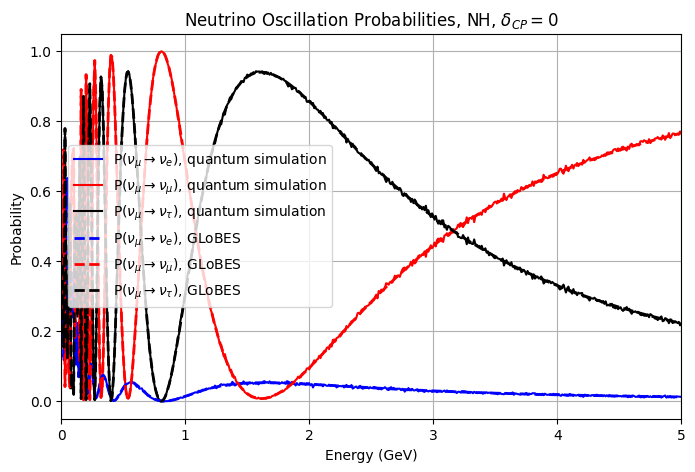

In [11]:
# Define mixing angles (in radians) and CP phase



theta_12, theta_13, theta_23 = np.radians([33.68, 8.56, 43.3])  # nu-fit values for NH
delta_CP = np.radians(0)
particle = "particle"
if particle=="particle":
    cp_sign=1
elif particle=="anti-particle":
    cp_sign=-1

# Define the PMNS matrix and embed it in a 4x4 unitary
def PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP):
    c12, s12 = np.cos(theta_12), np.sin(theta_12)
    c13, s13 = np.cos(theta_13), np.sin(theta_13)
    c23, s23 = np.cos(theta_23), np.sin(theta_23)
    e_idelta = np.exp(-1j * delta_CP * cp_sign)
    e_ideltap = np.exp(1j * delta_CP * cp_sign)

    # 3x3 PMNS matrix
    U = np.array([
        [c12 * c13, s12 * c13, s13 * e_idelta],
        [-s12 * c23 - c12 * s23 * s13 * e_ideltap, c12 * c23 - s12 * s23 * s13 * e_ideltap, s23 * c13],
        [s12 * s23 - c12 * c23 * s13 * e_ideltap, -c12 * s23 - s12 * c23 * s13 * e_ideltap, c23 * c13]
    ], dtype=complex)


    # Embed in 4x4 matrix
    U_4x4 = np.eye(4, dtype=complex)
    U_4x4[:3, :3] = U
    return U_4x4

# Project to unitary (optional for numerical stability)
def project_to_unitary(U):
    U_svd, _, Vh = svd(U)
    return U_svd @ Vh

# Constants for matter effects
G_F = 1.166e-5  # Fermi constant in GeV^-2
sqrt2 = np.sqrt(2)
rho = 2.8  # Earth crust density in g/cm^3
Ye = 0.5   # Electron fraction
Na = 6.022e23  # Avogadro number
sDm2 = 7.49e-5  # Delta_21 in eV^2
lDm2 = 2.513e-3  # Delta_31 in eV^2
hbar = 6.582e-16  # eV·s
c = 3e8  # m/s
L = 810 * 1e3  # NOvA baseline in meters
t = L / c  # time in seconds
# Convert Ne from cm^-3 to m^-3
Ne_cm3 = Ye * rho * Na
Ne_m3 = Ne_cm3 * 1e6


Vcc=cp_sign * 0.5 * 7.6e-14 * rho
print (Vcc)

# Mass-squared values (relative to m1)
m1, m2, m3 = 0, sDm2, lDm2
M2_3x3 = np.diag([m1, m2, m3])

# Lists to store energy values and probabilities
E_list = []
P_nue_list = []
P_numu_list = []
P_nutau_list = []
E_values = np.arange(0.01, 5.001, 0.01)

U_PMNS_3x3 = PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP)[:3, :3]
U_PMNS_3x3, _ = qr(U_PMNS_3x3)

for E in E_values:
    qc = QuantumCircuit(2, 2)

    # Initial state (|00⟩ corresponds to ν_e)
    initial_state = 'mu'
    if initial_state == 'mu':
        qc.x(0)
    elif initial_state == 'tau':
        qc.x(1)
    state = Statevector.from_instruction(qc)
    #print("Statevector:", state)
    # Vacuum + matter Hamiltonian in flavour basis
    H_vac_3x3 = U_PMNS_3x3 @ M2_3x3 @ U_PMNS_3x3.conj().T 
    V_3x3 = np.diag([2*E*1e9*Vcc, 0, 0])
    H_flavour_3x3 = (H_vac_3x3 + V_3x3)/(2*E*1e9)

    # Diagonalize
    eigvals, eigvecs = np.linalg.eigh(H_flavour_3x3)
    #print(f"E = {E}, eigenvalues = {eigvals}")
    #print(f"E = {E}, eigenvectors =\n{eigvecs}")
    # Build 4x4 unitaries
    U_eff = np.eye(4, dtype=complex)
    U_eff[:3, :3] = eigvecs
    #for row in U_eff:
        #print(" ".join(f"{elem:.6e}" for elem in row))
    evolution = np.eye(4, dtype=complex)
    evolution[:3, :3] = np.diag(np.exp(-1j * eigvals * t / ( hbar )))

    # Apply gates
    qc.unitary(UnitaryGate(U_eff.T.conj(), label="U"), [0, 1])
    state = Statevector.from_instruction(qc)
    #print("Statevector:", state)
    qc.unitary(UnitaryGate(evolution, label="e^(-iHt)"), [0, 1])
    state = Statevector.from_instruction(qc)
    #print("Statevector:", state)
    qc.unitary(UnitaryGate(U_eff, label="U†"), [0,1])
    state = Statevector.from_instruction(qc)
    #print("Statevector:", state)
    qc.measure([0, 1], [0, 1])

    # Simulate
    pqc = transpile(qc, simulator)
    job = simulator.run(pqc, shots=8192)
    counts = job.result().get_counts()
    total_counts = sum([counts.get(state, 0) for state in ['00', '01', '10']])

    P_nue = counts.get('00', 0) / total_counts
    P_numu = counts.get('01', 0) / total_counts
    P_nutau = counts.get('10', 0) / total_counts

    E_list.append(E)
    P_nue_list.append(P_nue)
    P_numu_list.append(P_numu)
    P_nutau_list.append(P_nutau)

# Plot
plt.figure(figsize=(8, 5))
# Load the classical GLoBES results from the file
glb_E, glb_P_nue, glb_P_numu, glb_P_nutau = np.loadtxt("prob_nue_numu_NOvA_initial_numu_matter.dat", unpack=True)

plt.plot(E_list, P_nue_list, label=r'P($\nu_\mu \to \nu_e$), quantum simulation', linestyle='-', color='blue')
plt.plot(E_list, P_numu_list, label=r'P($\nu_\mu \to \nu_\mu$), quantum simulation', linestyle='-', color='red')
plt.plot(E_list, P_nutau_list, label=r'P($\nu_\mu \to \nu_\tau$), quantum simulation', linestyle='-', color='black')

# Plot classical GLoBES results from the data file
plt.plot(glb_E, glb_P_nue, linestyle='--', color='blue', linewidth=2, label=r'P($\nu_\mu \to \nu_e$), GLoBES')
plt.plot(glb_E, glb_P_numu, linestyle='--', color='red', linewidth=2, label=r'P($\nu_\mu \to \nu_\mu$), GLoBES')
plt.plot(glb_E, glb_P_nutau, linestyle='--', color='black', linewidth=2, label=r'P($\nu_\mu \to \nu_\tau$), GLoBES')
plt.xlim(0, 5)
plt.xlabel("Energy (GeV)")
plt.ylabel("Probability")
plt.title("Neutrino Oscillation Probabilities, NH, $\delta_{CP}=0$")
plt.legend()
plt.grid()
plt.show()


<>:144: SyntaxWarning: invalid escape sequence '\d'
<>:144: SyntaxWarning: invalid escape sequence '\d'
/var/folders/sv/wfk5zngj3bv7b7v1ypmr9d_w0000gn/T/ipykernel_8308/2908296869.py:144: SyntaxWarning: invalid escape sequence '\d'
  plt.title("Neutrino Oscillation Probabilities, NH, $\delta_{CP}=-90^\circ$")


1.0639999999999999e-13


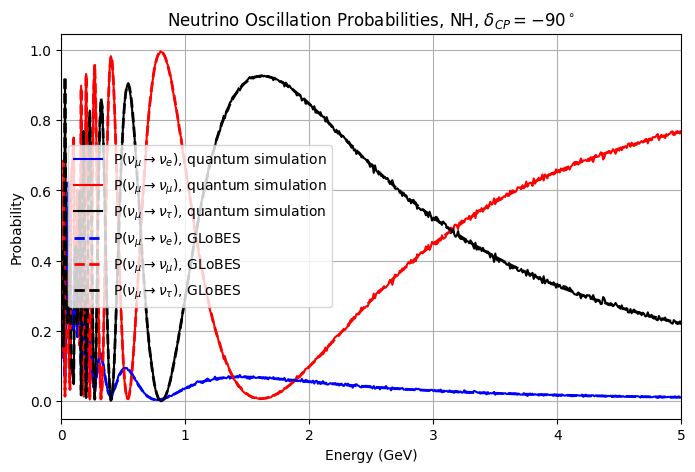

In [13]:
# Define mixing angles (in radians) and CP phase



theta_12, theta_13, theta_23 = np.radians([33.68, 8.56, 43.3])  # nu-fit values for NH
delta_CP = np.radians(-90)
particle = "particle"
if particle=="particle":
    cp_sign=1
elif particle=="anti-particle":
    cp_sign=-1

# Define the PMNS matrix and embed it in a 4x4 unitary
def PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP):
    c12, s12 = np.cos(theta_12), np.sin(theta_12)
    c13, s13 = np.cos(theta_13), np.sin(theta_13)
    c23, s23 = np.cos(theta_23), np.sin(theta_23)
    e_idelta = np.exp(-1j * delta_CP * cp_sign)
    e_ideltap = np.exp(1j * delta_CP * cp_sign)

    # 3x3 PMNS matrix
    U = np.array([
        [c12 * c13, s12 * c13, s13 * e_idelta],
        [-s12 * c23 - c12 * s23 * s13 * e_ideltap, c12 * c23 - s12 * s23 * s13 * e_ideltap, s23 * c13],
        [s12 * s23 - c12 * c23 * s13 * e_ideltap, -c12 * s23 - s12 * c23 * s13 * e_ideltap, c23 * c13]
    ], dtype=complex)


    # Embed in 4x4 matrix
    U_4x4 = np.eye(4, dtype=complex)
    U_4x4[:3, :3] = U
    return U_4x4

# Project to unitary (optional for numerical stability)
def project_to_unitary(U):
    U_svd, _, Vh = svd(U)
    return U_svd @ Vh

# Constants for matter effects
G_F = 1.166e-5  # Fermi constant in GeV^-2
sqrt2 = np.sqrt(2)
rho = 2.8  # Earth crust density in g/cm^3
Ye = 0.5   # Electron fraction
Na = 6.022e23  # Avogadro number
sDm2 = 7.49e-5  # Delta_21 in eV^2
lDm2 = 2.513e-3  # Delta_31 in eV^2
hbar = 6.582e-16  # eV·s
c = 3e8  # m/s
L = 810 * 1e3  # NOvA baseline in meters
t = L / c  # time in seconds
# Convert Ne from cm^-3 to m^-3
Ne_cm3 = Ye * rho * Na
Ne_m3 = Ne_cm3 * 1e6


Vcc=cp_sign * 0.5 * 7.6e-14 *rho
print (Vcc)

# Mass-squared values (relative to m1)
m1, m2, m3 = 0, sDm2, lDm2
M2_3x3 = np.diag([m1, m2, m3])

# Lists to store energy values and probabilities
E_list = []
P_nue_list = []
P_numu_list = []
P_nutau_list = []
E_values = np.arange(0.01, 5.001, 0.01)

U_PMNS_3x3 = PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP)[:3, :3]
#U_PMNS_3x3, _ = qr(U_PMNS_3x3)

for E in E_values:
    qc = QuantumCircuit(2, 2)

    # Initial state (|00⟩ corresponds to ν_e)
    initial_state = 'mu'
    if initial_state == 'mu':
        qc.x(0)
    elif initial_state == 'tau':
        qc.x(1)
    state = Statevector.from_instruction(qc)
    #print("Statevector:", state)
    # Vacuum + matter Hamiltonian in flavour basis
    H_vac_3x3 = U_PMNS_3x3 @ M2_3x3 @ U_PMNS_3x3.conj().T 
    V_3x3 = np.diag([2*E*1e9*Vcc, 0, 0])
    H_flavour_3x3 = (H_vac_3x3 + V_3x3)/(2*E*1e9)

    # Diagonalize
    eigvals, eigvecs = np.linalg.eigh(H_flavour_3x3)
    #print(f"E = {E}, eigenvalues = {eigvals}")
    #print(f"E = {E}, eigenvectors =\n{eigvecs}")
    # Build 4x4 unitaries
    U_eff = np.eye(4, dtype=complex)
    U_eff[:3, :3] = eigvecs
    #for row in U_eff:
        #print(" ".join(f"{elem:.6e}" for elem in row))
    evolution = np.eye(4, dtype=complex)
    evolution[:3, :3] = np.diag(np.exp(-1j * eigvals * t / ( hbar )))

    # Apply gates
    qc.unitary(UnitaryGate(U_eff.T.conj(), label="U"), [0, 1])
    state = Statevector.from_instruction(qc)
    #print("Statevector:", state)
    qc.unitary(UnitaryGate(evolution, label="e^(-iHt)"), [0, 1])
    state = Statevector.from_instruction(qc)
    #print("Statevector:", state)
    qc.unitary(UnitaryGate(U_eff, label="U†"), [0,1])
    state = Statevector.from_instruction(qc)
    #print("Statevector:", state)
    qc.measure([0, 1], [0, 1])

    # Simulate
    pqc = transpile(qc, simulator)
    job = simulator.run(pqc, shots=8192)
    counts = job.result().get_counts()
    total_counts = sum([counts.get(state, 0) for state in ['00', '01', '10']])

    P_nue = counts.get('00', 0) / total_counts
    P_numu = counts.get('01', 0) / total_counts
    P_nutau = counts.get('10', 0) / total_counts

    E_list.append(E)
    P_nue_list.append(P_nue)
    P_numu_list.append(P_numu)
    P_nutau_list.append(P_nutau)

# Plot
plt.figure(figsize=(8, 5))
# Load the classical GLoBES results from the file
glb_E, glb_P_nue, glb_P_numu, glb_P_nutau = np.loadtxt("prob_nue_numu_NOvA_initial_numu_matter_NH_dcp-90.dat", unpack=True)

plt.plot(E_list, P_nue_list, label=r'P($\nu_\mu \to \nu_e$), quantum simulation', linestyle='-', color='blue')
plt.plot(E_list, P_numu_list, label=r'P($\nu_\mu \to \nu_\mu$), quantum simulation', linestyle='-', color='red')
plt.plot(E_list, P_nutau_list, label=r'P($\nu_\mu \to \nu_\tau$), quantum simulation', linestyle='-', color='black')

# Plot classical GLoBES results from the data file
plt.plot(glb_E, glb_P_nue, linestyle='--', color='blue', linewidth=2, label=r'P($\nu_\mu \to \nu_e$), GLoBES')
plt.plot(glb_E, glb_P_numu, linestyle='--', color='red', linewidth=2, label=r'P($\nu_\mu \to \nu_\mu$), GLoBES')
plt.plot(glb_E, glb_P_nutau, linestyle='--', color='black', linewidth=2, label=r'P($\nu_\mu \to \nu_\tau$), GLoBES')
plt.xlim(0, 5)
plt.xlabel("Energy (GeV)")
plt.ylabel("Probability")
plt.title("Neutrino Oscillation Probabilities, NH, $\delta_{CP}=-90^\circ$")
plt.legend()
plt.grid()
plt.show()


<>:140: SyntaxWarning: invalid escape sequence '\d'
<>:140: SyntaxWarning: invalid escape sequence '\d'
/var/folders/sv/wfk5zngj3bv7b7v1ypmr9d_w0000gn/T/ipykernel_8308/2459174570.py:140: SyntaxWarning: invalid escape sequence '\d'
  plt.title("Neutrino Oscillation Probabilities, NH, $\delta_{CP}=90^\circ")


1.0639999999999999e-13


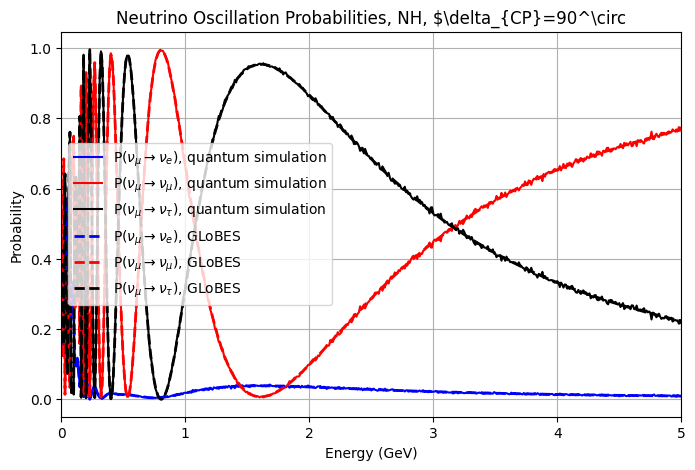

In [9]:
# Define mixing angles (in radians) and CP phase



theta_12, theta_13, theta_23 = np.radians([33.68, 8.56, 43.3])  # nu-fit values for NH
delta_CP = np.radians(+90)
particle = "particle"
if particle=="particle":
    cp_sign=1
elif particle=="anti-particle":
    cp_sign=-1

# Define the PMNS matrix and embed it in a 4x4 unitary
def PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP):
    c12, s12 = np.cos(theta_12), np.sin(theta_12)
    c13, s13 = np.cos(theta_13), np.sin(theta_13)
    c23, s23 = np.cos(theta_23), np.sin(theta_23)
    e_idelta = np.exp(-1j * delta_CP * cp_sign)
    e_ideltap = np.exp(1j * delta_CP * cp_sign)

    # 3x3 PMNS matrix
    U = np.array([
        [c12 * c13, s12 * c13, s13 * e_idelta],
        [-s12 * c23 - c12 * s23 * s13 * e_ideltap, c12 * c23 - s12 * s23 * s13 * e_ideltap, s23 * c13],
        [s12 * s23 - c12 * c23 * s13 * e_ideltap, -c12 * s23 - s12 * c23 * s13 * e_ideltap, c23 * c13]
    ], dtype=complex)


    # Embed in 4x4 matrix
    U_4x4 = np.eye(4, dtype=complex)
    U_4x4[:3, :3] = U
    return U_4x4


# Constants for matter effects
G_F = 1.166e-5  # Fermi constant in GeV^-2
sqrt2 = np.sqrt(2)
rho = 2.8  # Earth crust density in g/cm^3
Ye = 0.5   # Electron fraction
Na = 6.022e23  # Avogadro number
sDm2 = 7.49e-5  # Delta_21 in eV^2
lDm2 = 2.513e-3  # Delta_31 in eV^2
hbar = 6.582e-16  # eV·s
c = 3e8  # m/s
L = 810 * 1e3  # NOvA baseline in meters
t = L / c  # time in seconds
# Convert Ne from cm^-3 to m^-3
Ne_cm3 = Ye * rho * Na
Ne_m3 = Ne_cm3 * 1e6


Vcc=cp_sign * 0.5 * 7.6e-14 *rho
print (Vcc)

# Mass-squared values (relative to m1)
m1, m2, m3 = 0, sDm2, lDm2
M2_3x3 = np.diag([m1, m2, m3])

# Lists to store energy values and probabilities
E_list = []
P_nue_list = []
P_numu_list = []
P_nutau_list = []
E_values = np.arange(0.01, 5.001, 0.01)

U_PMNS_3x3 = PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP)[:3, :3]
#U_PMNS_3x3, _ = qr(U_PMNS_3x3)

for E in E_values:
    qc = QuantumCircuit(2, 2)

    # Initial state (|00⟩ corresponds to ν_e)
    initial_state = 'mu'
    if initial_state == 'mu':
        qc.x(0)
    elif initial_state == 'tau':
        qc.x(1)
    state = Statevector.from_instruction(qc)
    #print("Statevector:", state)
    # Vacuum + matter Hamiltonian in flavour basis
    H_vac_3x3 = U_PMNS_3x3 @ M2_3x3 @ U_PMNS_3x3.conj().T 
    V_3x3 = np.diag([2*E*1e9*Vcc, 0, 0])
    H_flavour_3x3 = (H_vac_3x3 + V_3x3)/(2*E*1e9)

    # Diagonalize
    eigvals, eigvecs = np.linalg.eigh(H_flavour_3x3)
    #print(f"E = {E}, eigenvalues = {eigvals}")
    #print(f"E = {E}, eigenvectors =\n{eigvecs}")
    # Build 4x4 unitaries
    U_eff = np.eye(4, dtype=complex)
    U_eff[:3, :3] = eigvecs
    #for row in U_eff:
        #print(" ".join(f"{elem:.6e}" for elem in row))
    evolution = np.eye(4, dtype=complex)
    evolution[:3, :3] = np.diag(np.exp(-1j * eigvals * t / ( hbar )))

    # Apply gates
    qc.unitary(UnitaryGate(U_eff.T.conj(), label="U"), [0, 1])
    state = Statevector.from_instruction(qc)
    #print("Statevector:", state)
    qc.unitary(UnitaryGate(evolution, label="e^(-iHt)"), [0, 1])
    state = Statevector.from_instruction(qc)
    #print("Statevector:", state)
    qc.unitary(UnitaryGate(U_eff, label="U†"), [0,1])
    state = Statevector.from_instruction(qc)
    #print("Statevector:", state)
    qc.measure([0, 1], [0, 1])

    # Simulate
    pqc = transpile(qc, simulator)
    job = simulator.run(pqc, shots=8192)
    counts = job.result().get_counts()
    total_counts = sum([counts.get(state, 0) for state in ['00', '01', '10']])

    P_nue = counts.get('00', 0) / total_counts
    P_numu = counts.get('01', 0) / total_counts
    P_nutau = counts.get('10', 0) / total_counts

    E_list.append(E)
    P_nue_list.append(P_nue)
    P_numu_list.append(P_numu)
    P_nutau_list.append(P_nutau)

# Plot
plt.figure(figsize=(8, 5))
# Load the classical GLoBES results from the file
glb_E, glb_P_nue, glb_P_numu, glb_P_nutau = np.loadtxt("prob_nue_numu_NOvA_initial_numu_matter_NH_dcp90.dat", unpack=True)

plt.plot(E_list, P_nue_list, label=r'P($\nu_\mu \to \nu_e$), quantum simulation', linestyle='-', color='blue')
plt.plot(E_list, P_numu_list, label=r'P($\nu_\mu \to \nu_\mu$), quantum simulation', linestyle='-', color='red')
plt.plot(E_list, P_nutau_list, label=r'P($\nu_\mu \to \nu_\tau$), quantum simulation', linestyle='-', color='black')

# Plot classical GLoBES results from the data file
plt.plot(glb_E, glb_P_nue, linestyle='--', color='blue', linewidth=2, label=r'P($\nu_\mu \to \nu_e$), GLoBES')
plt.plot(glb_E, glb_P_numu, linestyle='--', color='red', linewidth=2, label=r'P($\nu_\mu \to \nu_\mu$), GLoBES')
plt.plot(glb_E, glb_P_nutau, linestyle='--', color='black', linewidth=2, label=r'P($\nu_\mu \to \nu_\tau$), GLoBES')
plt.xlim(0, 5)
plt.xlabel("Energy (GeV)")
plt.ylabel("Probability")
plt.title("Neutrino Oscillation Probabilities, NH, $\delta_{CP}=90^\circ")
plt.legend()
plt.grid()
plt.show()


<>:144: SyntaxWarning: invalid escape sequence '\d'
<>:144: SyntaxWarning: invalid escape sequence '\d'
/var/folders/sv/wfk5zngj3bv7b7v1ypmr9d_w0000gn/T/ipykernel_8308/867776914.py:144: SyntaxWarning: invalid escape sequence '\d'
  plt.title("Neutrino Oscillation Probabilities,NH, $\delta_{CP}=-90^\circ")


-1.0639999999999999e-13


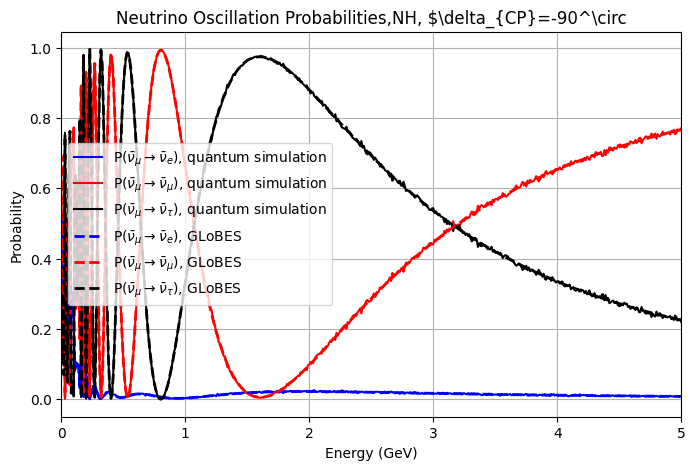

In [15]:
# Define mixing angles (in radians) and CP phase



theta_12, theta_13, theta_23 = np.radians([33.68, 8.56, 43.3])  # nu-fit values for NH
delta_CP = np.radians(-90)
particle = "anti-particle"
if particle=="particle":
    cp_sign=1
elif particle=="anti-particle":
    cp_sign=-1

# Define the PMNS matrix and embed it in a 4x4 unitary
def PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP):
    c12, s12 = np.cos(theta_12), np.sin(theta_12)
    c13, s13 = np.cos(theta_13), np.sin(theta_13)
    c23, s23 = np.cos(theta_23), np.sin(theta_23)
    e_idelta = np.exp(-1j * delta_CP * cp_sign)
    e_ideltap = np.exp(1j * delta_CP * cp_sign)

    # 3x3 PMNS matrix
    U = np.array([
        [c12 * c13, s12 * c13, s13 * e_idelta],
        [-s12 * c23 - c12 * s23 * s13 * e_ideltap, c12 * c23 - s12 * s23 * s13 * e_ideltap, s23 * c13],
        [s12 * s23 - c12 * c23 * s13 * e_ideltap, -c12 * s23 - s12 * c23 * s13 * e_ideltap, c23 * c13]
    ], dtype=complex)


    # Embed in 4x4 matrix
    U_4x4 = np.eye(4, dtype=complex)
    U_4x4[:3, :3] = U
    return U_4x4

# Project to unitary (optional for numerical stability)
def project_to_unitary(U):
    U_svd, _, Vh = svd(U)
    return U_svd @ Vh

# Constants for matter effects
G_F = 1.166e-5  # Fermi constant in GeV^-2
sqrt2 = np.sqrt(2)
rho = 2.8  # Earth crust density in g/cm^3
Ye = 0.5   # Electron fraction
Na = 6.022e23  # Avogadro number
sDm2 = 7.49e-5  # Delta_21 in eV^2
lDm2 = 2.513e-3  # Delta_31 in eV^2
hbar = 6.582e-16  # eV·s
c = 3e8  # m/s
L = 810 * 1e3  # NOvA baseline in meters
t = L / c  # time in seconds
# Convert Ne from cm^-3 to m^-3
Ne_cm3 = Ye * rho * Na
Ne_m3 = Ne_cm3 * 1e6


Vcc=cp_sign * 0.5 * 7.6e-14 *rho
print (Vcc)

# Mass-squared values (relative to m1)
m1, m2, m3 = 0, sDm2, lDm2
M2_3x3 = np.diag([m1, m2, m3])

# Lists to store energy values and probabilities
E_list = []
P_nue_list = []
P_numu_list = []
P_nutau_list = []
E_values = np.arange(0.01, 5.001, 0.01)

U_PMNS_3x3 = PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP)[:3, :3]
#U_PMNS_3x3, _ = qr(U_PMNS_3x3)

for E in E_values:
    qc = QuantumCircuit(2, 2)

    # Initial state (|00⟩ corresponds to ν_e)
    initial_state = 'mu'
    if initial_state == 'mu':
        qc.x(0)
    elif initial_state == 'tau':
        qc.x(1)
    state = Statevector.from_instruction(qc)
    #print("Statevector:", state)
    # Vacuum + matter Hamiltonian in flavour basis
    H_vac_3x3 = U_PMNS_3x3 @ M2_3x3 @ U_PMNS_3x3.conj().T 
    V_3x3 = np.diag([2*E*1e9*Vcc, 0, 0])
    H_flavour_3x3 = (H_vac_3x3 + V_3x3)/(2*E*1e9)

    # Diagonalize
    eigvals, eigvecs = np.linalg.eigh(H_flavour_3x3)
    #print(f"E = {E}, eigenvalues = {eigvals}")
    #print(f"E = {E}, eigenvectors =\n{eigvecs}")
    # Build 4x4 unitaries
    U_eff = np.eye(4, dtype=complex)
    U_eff[:3, :3] = eigvecs
    #for row in U_eff:
       # print(" ".join(f"{elem:.6e}" for elem in row))
    evolution = np.eye(4, dtype=complex)
    evolution[:3, :3] = np.diag(np.exp(-1j * eigvals * t / ( hbar )))

    # Apply gates
    qc.unitary(UnitaryGate(U_eff.T.conj(), label="U"), [0, 1])
    state = Statevector.from_instruction(qc)
    #print("Statevector:", state)
    qc.unitary(UnitaryGate(evolution, label="e^(-iHt)"), [0, 1])
    state = Statevector.from_instruction(qc)
    #print("Statevector:", state)
    qc.unitary(UnitaryGate(U_eff, label="U†"), [0,1])
    state = Statevector.from_instruction(qc)
    #print("Statevector:", state)
    qc.measure([0, 1], [0, 1])

    # Simulate
    pqc = transpile(qc, simulator)
    job = simulator.run(pqc, shots=8192)
    counts = job.result().get_counts()
    total_counts = sum([counts.get(state, 0) for state in ['00', '01', '10']])

    P_nue = counts.get('00', 0) / total_counts
    P_numu = counts.get('01', 0) / total_counts
    P_nutau = counts.get('10', 0) / total_counts

    E_list.append(E)
    P_nue_list.append(P_nue)
    P_numu_list.append(P_numu)
    P_nutau_list.append(P_nutau)

# Plot
plt.figure(figsize=(8, 5))
# Load the classical GLoBES results from the file
glb_E, glb_P_nue, glb_P_numu, glb_P_nutau = np.loadtxt("prob_nuebar_numubar_NOvA_initial_numubar_matter_NH_dcp-90.dat", unpack=True)

plt.plot(E_list, P_nue_list, label=r'P($\bar{\nu}_\mu \to \bar{\nu}_e$), quantum simulation', linestyle='-', color='blue')
plt.plot(E_list, P_numu_list, label=r'P($\bar{\nu}_\mu \to \bar{\nu}_\mu$), quantum simulation', linestyle='-', color='red')
plt.plot(E_list, P_nutau_list, label=r'P($\bar{\nu}_\mu \to \bar{\nu}_\tau$), quantum simulation', linestyle='-', color='black')

# Plot classical GLoBES results from the data file
plt.plot(glb_E, glb_P_nue, linestyle='--', color='blue', linewidth=2, label=r'P($\bar{\nu}_\mu \to \bar{\nu}_e$), GLoBES')
plt.plot(glb_E, glb_P_numu, linestyle='--', color='red', linewidth=2, label=r'P($\bar{\nu}_\mu \to \bar{\nu}_\mu$), GLoBES')
plt.plot(glb_E, glb_P_nutau, linestyle='--', color='black', linewidth=2, label=r'P($\bar{\nu}_\mu \to \bar{\nu}_\tau$), GLoBES')
plt.xlim(0, 5)
plt.xlabel("Energy (GeV)")
plt.ylabel("Probability")
plt.title("Neutrino Oscillation Probabilities,NH, $\delta_{CP}=-90^\circ")
plt.legend()
plt.grid()
plt.show()
